<a href="https://colab.research.google.com/github/LINWOO0099/machine-learning/blob/main/part_1_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# ==============================
# 1. Load Dataset
# ==============================

df = pd.read_excel("online_retail_II.xlsx")
print(df)
print("first 5 row ")
print(df.head())
print("\nData Types:")
print(df.dtypes)
print("\nShape:")
print(df.shape)


       Invoice StockCode                          Description  Quantity  \
0       489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1       489434    79323P                   PINK CHERRY LIGHTS        12   
2       489434    79323W                  WHITE CHERRY LIGHTS        12   
3       489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4       489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   
...        ...       ...                                  ...       ...   
525456  538171     22271                 FELTCRAFT DOLL ROSIE         2   
525457  538171     22750         FELTCRAFT PRINCESS LOLA DOLL         1   
525458  538171     22751       FELTCRAFT PRINCESS OLIVIA DOLL         1   
525459  538171     20970   PINK FLORAL FELTCRAFT SHOULDER BAG         2   
525460  538171     21931               JUMBO STORAGE BAG SUKI         2   

               InvoiceDate  Price  Customer ID         Country  
0      2009-12-01 07:45:00   6.95 

In [24]:
# ==============================
# 2. Null Value Analysis
# ==============================

null_count = df.isnull()
print(null_count)
print(null_count.sum())
null_percentage=df.isnull().sum()/df.shape[0]*100
print(null_percentage)
null_table={
    "Missing Values":null_count.sum(),
    "Missing Percentage":null_percentage
}

print("\nNull Analysis:")
print(null_table)


print("\nColumns above 20% missing:")
print(null_percentage[null_percentage > 20])


# Fill numeric columns below 20% missing using median
for col in df.select_dtypes(include=np.number):

    missing_percent = (
        df[col].isnull().sum()
        /
        df.shape[0]
    )*100

    if missing_percent < 20:

        print(f"Filling {col} with median")
        df[col] = df[col].fillna(df[col].median())


        Invoice  StockCode  Description  Quantity  InvoiceDate  Price  \
0         False      False        False     False        False  False   
1         False      False        False     False        False  False   
2         False      False        False     False        False  False   
3         False      False        False     False        False  False   
4         False      False        False     False        False  False   
...         ...        ...          ...       ...          ...    ...   
525456    False      False        False     False        False  False   
525457    False      False        False     False        False  False   
525458    False      False        False     False        False  False   
525459    False      False        False     False        False  False   
525460    False      False        False     False        False  False   

        Customer ID  Country  
0             False    False  
1             False    False  
2             False    False  

In [39]:
# ==============================
# 3. Duplicate Removal
# ==============================
print("\nDuplicate ")
Duplicates=df.duplicated()
print(Duplicates.sum())
df=df.drop_duplicates()
print(df.shape)


Duplicate 
0
(518596, 8)


In [45]:
# ==============================
# 4. Data Type Correction
# ==============================
print("\nMemory before conversion:")
print(df.memory_usage(deep=True).sum())

# Convert InvoiceDate
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Convert CustomerID to string
df['Customer ID'] = pd.to_numeric(df['Customer ID'],errors="coerce")

# Convert Country to category

df["Country"] = df["Country"].astype(
    "category"
)


print("\nMemory after conversion:")
print(
    df.memory_usage(deep=True).sum()
)



Memory before conversion:
131303139

Memory after conversion:
99440862


In [63]:
# ==============================
# 5. Descriptive Statistics
# ==============================
print("\nDescriptive Statistics:")
print(df.describe())

print("\nSkewness:")

skew_values={}

for col in df.select_dtypes(include=np.number):

    skew_values[col]=df[col].skew()

skew_df=pd.Series(skew_values)

print(skew_df)
most_skewed = (
    skew_df.abs()
    .idxmax()
)
print(
    "\nMost skewed column:",
    most_skewed
)




Descriptive Statistics:
            Quantity                    InvoiceDate          Price  \
count  525461.000000                         525461  525461.000000   
mean       10.337667  2010-06-28 11:37:36.845017856       4.688834   
min     -9600.000000            2009-12-01 07:45:00  -53594.360000   
25%         1.000000            2010-03-21 12:20:00       1.250000   
50%         3.000000            2010-07-06 09:51:00       2.100000   
75%        10.000000            2010-10-15 12:45:00       4.210000   
max     19152.000000            2010-12-09 20:01:00   25111.090000   
std       107.424110                            NaN     146.126914   

         Customer ID  
count  417534.000000  
mean    15360.645478  
min     12346.000000  
25%     13983.000000  
50%     15311.000000  
75%     16799.000000  
max     18287.000000  
std      1680.811316  

Skewness:
Quantity        36.044617
Price         -140.768446
Customer ID     -0.016524
dtype: float64

Most skewed column: Price


In [58]:
# ==============================
# 6. IQR Outlier Detection
# ==============================
def find_outliers (column):
   Q1=df[column].quantile(0.25)
   Q3=df[column].quantile(0.75)
   IQR=Q3-Q1
   lower=Q1-(1.5*IQR)
   upper=Q3+(1.5*IQR)
   outliers = df[(df[column] < lower) | (df[column] > upper)]
   count = outliers.shape[0]
   return count


print(
    "\nQuantity outliers:",
    find_outliers("Quantity")
)


print(
    "Price outliers:",
    find_outliers("Price")
)



Quantity outliers: 57870
Price outliers: 35273


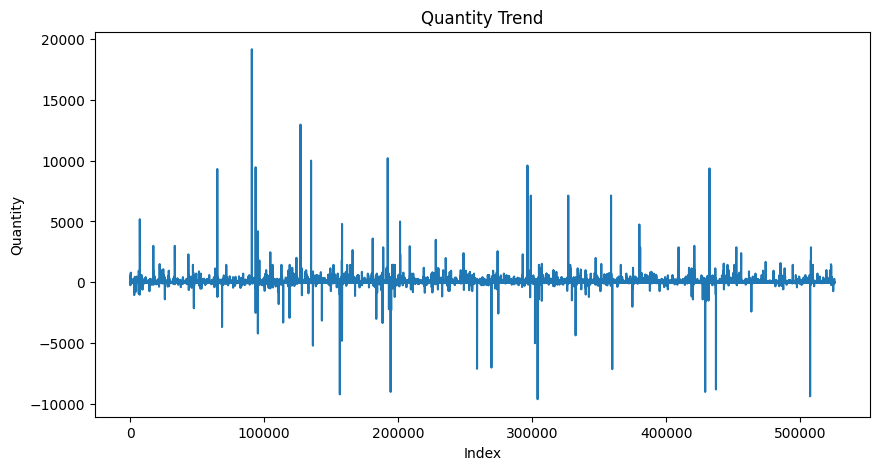

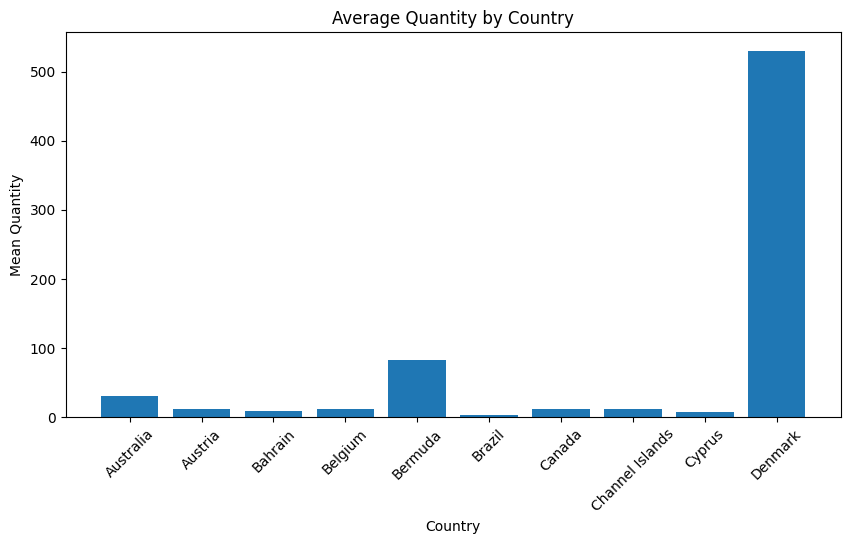

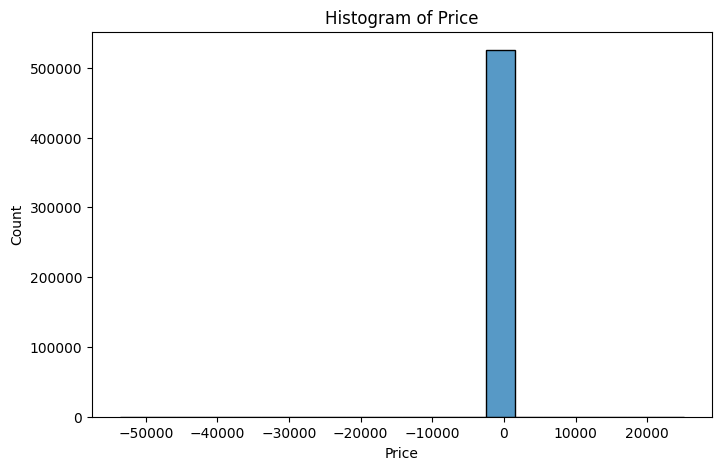

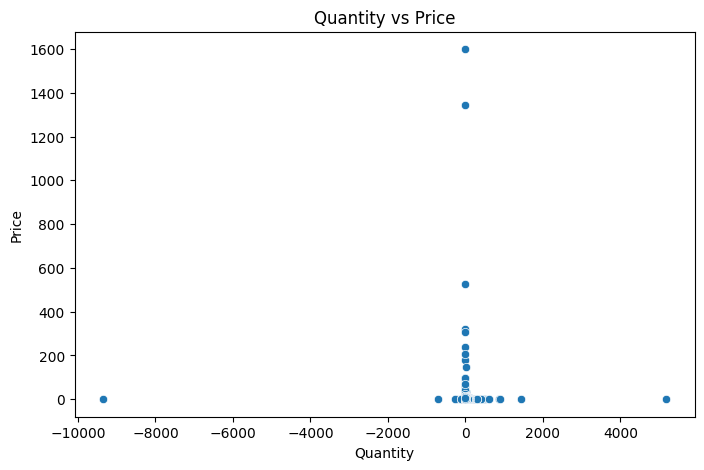

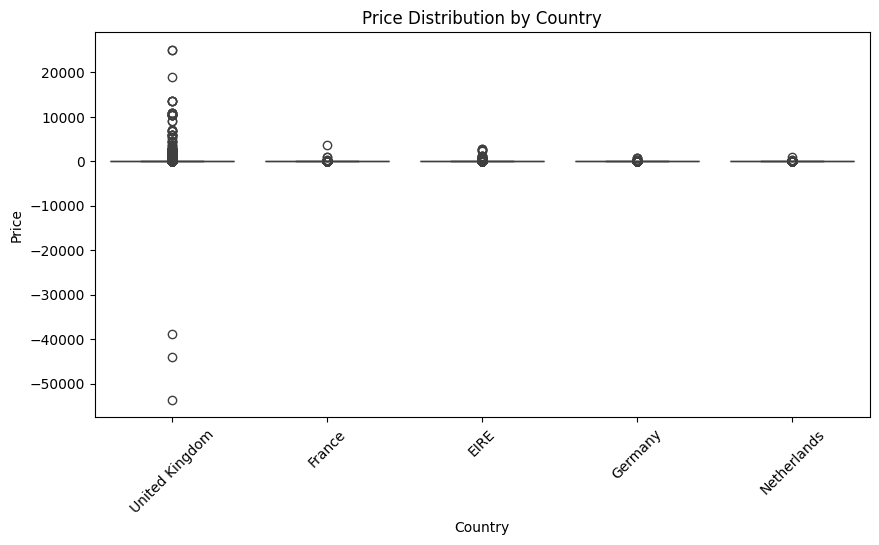

In [62]:
# Re-running Visualizations after updating 'most_skewed'
# ==============================
# 7. Visualizations
# ==============================


# Line plot

plt.figure(figsize=(10,5))

plt.plot(
    df.index,
    df["Quantity"]
)

plt.title("Quantity Trend")

plt.xlabel("Index")

plt.ylabel("Quantity")

plt.show()



# Bar chart

country_mean = (
    df.groupby("Country")
    ["Quantity"]
    .mean()
    .head(10)
)


plt.figure(figsize=(10,5))

plt.bar(
    country_mean.index,
    country_mean.values
)

plt.xticks(rotation=45)

plt.title(
    "Average Quantity by Country"
)

plt.xlabel("Country")

plt.ylabel("Mean Quantity")

plt.show()



# Histogram

plt.figure(figsize=(8,5))

sns.histplot(df[most_skewed],
    bins=20
)

plt.title(
    f"Histogram of {most_skewed}"
)

plt.show()



# Scatter plot

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df.sample(5000),
    x="Quantity",
    y="Price"
)

plt.title(
    "Quantity vs Price"
)

plt.show()



# Box plot

plt.figure(figsize=(10,5))

sns.boxplot(
    data=df[
        df["Country"].isin(
            df["Country"]
            .value_counts()
            .head(5)
            .index
        )
    ],
    x="Country",
    y="Price"
)

plt.xticks(rotation=45)

plt.title(
    "Price Distribution by Country"
)

plt.show()

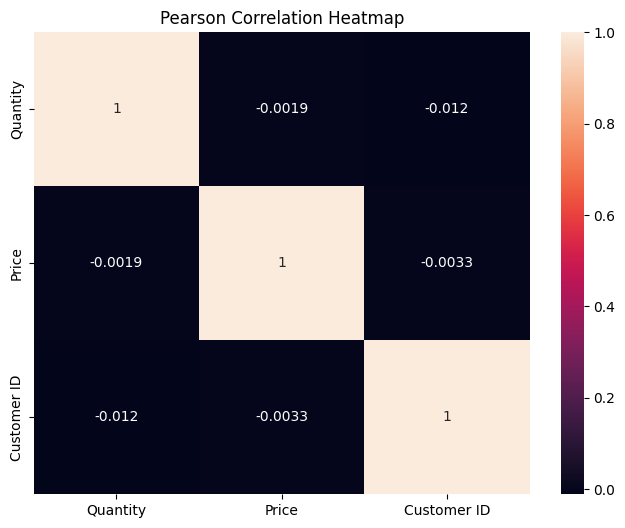

In [65]:
# ==============================
# 8. Correlation Heatmap
# ==============================
pearson = df.corr(numeric_only=True)
plt.figure(figsize=(8,6))

sns.heatmap(
    pearson,
    annot=True
)

plt.title(
    "Pearson Correlation Heatmap"
)

plt.show()



In [67]:
# ==============================
# 10. Imputation Comparison
# ==============================


print("\nMean and Median comparison:")
for col in ["Quantity","Price"]:

    print("\nColumn:",col)

    print(
        "Mean:",
        df[col].mean()
    )

    print(
        "Median:",
        df[col].median()
    )

# Refactor to avoid FutureWarning: Assign the result back to the column
df["Quantity"] = df["Quantity"].fillna(
    df["Quantity"].median()
)
df["Price"] = df["Price"].fillna(
    df["Price"].median()
)
print(
    "\nRemaining Null Values:"
)
print(
    df.isnull().sum()
)



Mean and Median comparison:

Column: Quantity
Mean: 10.337667305470815
Median: 3.0

Column: Price
Mean: 4.688834478676819
Median: 2.1

Remaining Null Values:
Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64


In [69]:
#===============================
# 11. Group Aggregation
# ==============================


group_result = (
    df.groupby("Country")
    ["Quantity"]
    .agg(
        ["mean","std","count"]
    )
)


print("\nGroup Aggregation:")

print(group_result)



Group Aggregation:
                            mean          std   count
Country                                              
Australia              30.662080    55.546241     654
Austria                12.065177    12.238360     537
Bahrain                 9.485981    10.833530     107
Belgium                11.366224    11.704198    1054
Bermuda                82.294118   271.785625      34
Brazil                  3.048387     3.672795      62
Canada                 11.610390     6.370483      77
Channel Islands        12.134658    26.362655     906
Cyprus                  7.889892    19.389427     554
Denmark               530.443925  1946.486043     428
EIRE                   19.514374    52.319163    9670
Finland                10.313559     8.783224     354
France                 12.902114   334.876209    5772
Germany                13.179112    21.883047    8129
Greece                 11.897485    11.130269     517
Hong Kong              30.342105    32.879802      76
Iceland 

In [70]:
# ==============================
# 12. Save Clean Dataset
# ==============================


df.to_csv(
    "cleaned_data.csv",
    index=False
)


print(
    "\ncleaned_data.csv created successfully"
)


cleaned_data.csv created successfully
